In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

output_path = Path(r"C:\Users\Ricardo\Documents\Projects\capstone_project\data\cleaned\local_projections_data\vc_LP_1_1.csv")

In [2]:
# load merged cleaned macro & early stage vc dataset
df = pd.read_csv(r"C:\Users\Ricardo\Documents\Projects\capstone_project\data\cleaned\cleaned_macro\merged_data.csv")
df.head(10)

,Unnamed: 0,quarter_year,year,quarter,deal value ($B),mps_shock,fundraising_activity,dry_powder,T10Y2Y,nasdaq_comp_index,real_gdp,gdp_def
0,0,2015-Q1,2015,Q1,5.229359,-0.0662,45.70,84.66,1.38,3.42113,0.89645,96.769
1,1,2015-Q2,2015,Q2,7.623194,-0.0324,45.70,84.66,1.71,1.73937,0.61749,97.325
2,2,2015-Q3,2015,Q3,7.339539,-0.0616,45.70,84.66,1.42,-7.63791,0.39945,97.583
3,3,2015-Q4,2015,Q4,6.333488,0.0819,45.70,84.66,1.21,8.04895,0.18431,97.581
4,4,2016-Q1,2016,Q1,6.852405,-0.1054,50.08,99.15,1.05,-2.78557,0.57785,97.496
5,5,2016-Q2,2016,Q2,7.369265,-0.0215,50.08,99.15,0.91,-0.55969,0.32061,98.159
6,6,2016-Q3,2016,Q3,5.885506,-0.0076,50.08,99.15,0.83,9.25022,0.70689,98.410
7,7,2016-Q4,2016,Q4,6.236586,0.0584,50.08,99.15,1.25,1.32997,0.55277,98.886
8,8,2017-Q1,2017,Q1,6.785671,-0.0650,49.69,109.97,1.13,9.36721,0.48571,99.390
9,9,2017-Q2,2017,Q2,7.039690,0.0493,49.69,109.97,0.93,3.79529,0.55831,99.650


In [3]:
# copy dataframe for manipulation
df_copy = df.copy()

# drop unneeded columns
df_copy.drop(columns=["Unnamed: 0", "quarter_year", "fundraising_activity", "dry_powder", "T10Y2Y"], inplace=True)
df_copy

,year,quarter,deal value ($B),mps_shock,nasdaq_comp_index,real_gdp,gdp_def
0,2015,Q1,5.229359,-0.0662,3.42113,0.89645,96.769
1,2015,Q2,7.623194,-0.0324,1.73937,0.61749,97.325
2,2015,Q3,7.339539,-0.0616,-7.63791,0.39945,97.583
3,2015,Q4,6.333488,0.0819,8.04895,0.18431,97.581
4,2016,Q1,6.852405,-0.1054,-2.78557,0.57785,97.496
5,2016,Q2,7.369265,-0.0215,-0.55969,0.32061,98.159
6,2016,Q3,5.885506,-0.0076,9.25022,0.70689,98.410
7,2016,Q4,6.236586,0.0584,1.32997,0.55277,98.886
8,2017,Q1,6.785671,-0.0650,9.36721,0.48571,99.390
9,2017,Q2,7.039690,0.0493,3.79529,0.55831,99.650


In [4]:
# rename columns for easier access
df_copy.rename(columns={" deal value ($B) ": "deal_value_billion_usd"}, inplace=True)
print(list(df_copy.columns))

['year', 'quarter', 'deal_value_billion_usd', 'mps_shock', 'nasdaq_comp_index', 'real_gdp', 'gdp_def']


In [5]:
# make sure rows are in true time order
df_copy = df_copy.sort_values(["year", "quarter"]).reset_index(drop=True)
df_copy.head()

,year,quarter,deal_value_billion_usd,mps_shock,nasdaq_comp_index,real_gdp,gdp_def
0,2015,Q1,5.229359,-0.0662,3.42113,0.89645,96.769
1,2015,Q2,7.623194,-0.0324,1.73937,0.61749,97.325
2,2015,Q3,7.339539,-0.0616,-7.63791,0.39945,97.583
3,2015,Q4,6.333488,0.0819,8.04895,0.18431,97.581
4,2016,Q1,6.852405,-0.1054,-2.78557,0.57785,97.496


In [6]:
# convert early deal_value_billion_usd (early stage) to real dollars (2017 USD)
df_copy['vc_real'] = df_copy['deal_value_billion_usd'] * 1e9 / (df_copy['gdp_def'] / 100)
df_copy.head()

,year,quarter,deal_value_billion_usd,mps_shock,nasdaq_comp_index,real_gdp,gdp_def,vc_real
0,2015,Q1,5.229359,-0.0662,3.42113,0.89645,96.769,5.403961e+09
1,2015,Q2,7.623194,-0.0324,1.73937,0.61749,97.325,7.832719e+09
2,2015,Q3,7.339539,-0.0616,-7.63791,0.39945,97.583,7.521329e+09
3,2015,Q4,6.333488,0.0819,8.04895,0.18431,97.581,6.490493e+09
4,2016,Q1,6.852405,-0.1054,-2.78557,0.57785,97.496,7.028397e+09


In [7]:
# compute quarterly log growth of real VC deal value
df_copy['dlog_vc'] = 100 * (np.log(df_copy['vc_real']) - np.log(df_copy['vc_real'].shift(1)))
df_copy.head()

,year,quarter,deal_value_billion_usd,mps_shock,nasdaq_comp_index,real_gdp,gdp_def,vc_real,dlog_vc
0,2015,Q1,5.229359,-0.0662,3.42113,0.89645,96.769,5.403961e+09,NaN
1,2015,Q2,7.623194,-0.0324,1.73937,0.61749,97.325,7.832719e+09,37.117752
2,2015,Q3,7.339539,-0.0616,-7.63791,0.39945,97.583,7.521329e+09,-4.056687
3,2015,Q4,6.333488,0.0819,8.04895,0.18431,97.581,6.490493e+09,-14.740430
4,2016,Q1,6.852405,-0.1054,-2.78557,0.57785,97.496,7.028397e+09,7.962003


In [8]:
# mps to basis points
df_copy["mps_bp"] = df_copy["mps_shock"] * 100

# mps_bp to 25 basis points so 1 unit = 25 bp
df_copy["mps_25bp"] = df_copy["mps_bp"] / 25
df_copy.head()

,year,quarter,deal_value_billion_usd,mps_shock,nasdaq_comp_index,real_gdp,gdp_def,vc_real,dlog_vc,mps_bp,mps_25bp
0,2015,Q1,5.229359,-0.0662,3.42113,0.89645,96.769,5.403961e+09,NaN,-6.62,-0.2648
1,2015,Q2,7.623194,-0.0324,1.73937,0.61749,97.325,7.832719e+09,37.117752,-3.24,-0.1296
2,2015,Q3,7.339539,-0.0616,-7.63791,0.39945,97.583,7.521329e+09,-4.056687,-6.16,-0.2464
3,2015,Q4,6.333488,0.0819,8.04895,0.18431,97.581,6.490493e+09,-14.740430,8.19,0.3276
4,2016,Q1,6.852405,-0.1054,-2.78557,0.57785,97.496,7.028397e+09,7.962003,-10.54,-0.4216


In [9]:
# drop unnecessary variables
df_copy.drop(columns=["deal_value_billion_usd", "mps_shock", "gdp_def", "vc_real", "mps_bp"], inplace=True)

# reorganize dataset
df_copy = df_copy[["year", "quarter", "dlog_vc", "mps_25bp", "real_gdp", "nasdaq_comp_index"]]
df_copy

,year,quarter,dlog_vc,mps_25bp,real_gdp,nasdaq_comp_index
0,2015,Q1,NaN,-0.2648,0.89645,3.42113
1,2015,Q2,37.117752,-0.1296,0.61749,1.73937
2,2015,Q3,-4.056687,-0.2464,0.39945,-7.63791
3,2015,Q4,-14.740430,0.3276,0.18431,8.04895
4,2016,Q1,7.962003,-0.4216,0.57785,-2.78557
5,2016,Q2,6.594098,-0.0860,0.32061,-0.55969
6,2016,Q3,-22.737907,-0.0304,0.70689,9.25022
7,2016,Q4,5.311492,0.2336,0.55277,1.32997
8,2017,Q1,7.929647,-0.2600,0.48571,9.36721
9,2017,Q2,3.413843,0.1972,0.55831,3.79529


## Data Exploration

In [10]:
# summary statistics
df_copy[['dlog_vc', 'mps_25bp', 'real_gdp', 'nasdaq_comp_index']].describe().T

,count,mean,std,min,25%,50%,75%,max
dlog_vc,40.0,1.555774,19.780409,-45.193572,-10.44509,3.314169,10.250923,47.637484
mps_25bp,35.0,0.029314,0.380427,-1.621600,-0.10780,0.071600,0.209600,0.578800
real_gdp,41.0,0.588481,1.839761,-8.204320,0.45882,0.679560,0.840510,7.475750
nasdaq_comp_index,41.0,3.159663,9.840324,-25.418140,-0.55969,3.795290,9.065970,26.721160


In [11]:
df_copy.isna().sum()

year                 0
quarter              0
dlog_vc              1
mps_25bp             6
real_gdp             0
nasdaq_comp_index    0
dtype: int64

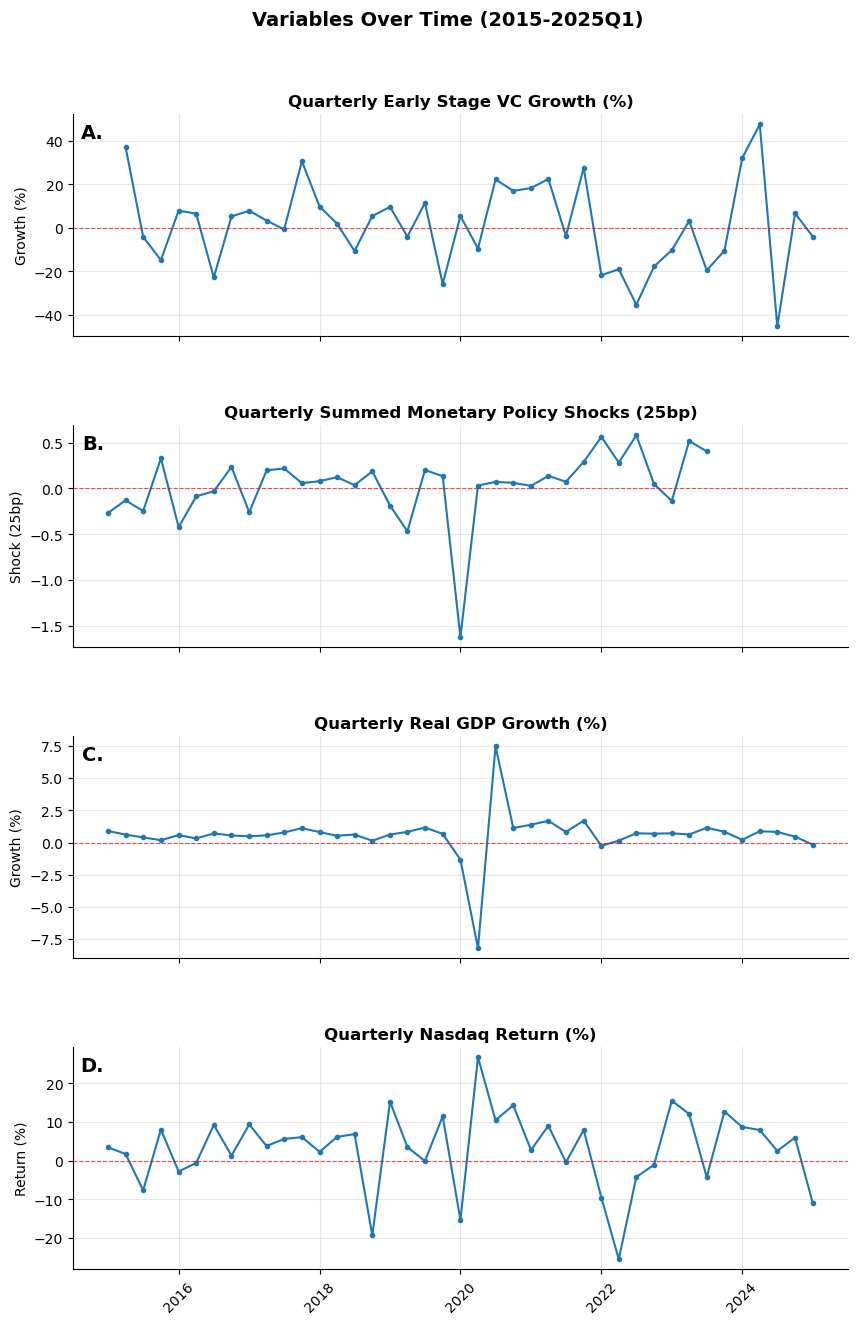

In [98]:
# create date column for plotting
df_copy["date"] = pd.PeriodIndex.from_fields(year=df_copy['year'], quarter=df_copy['quarter'].str[1].astype(int), freq='Q').to_timestamp()

variables = ['dlog_vc', 
             'mps_25bp', 
             'real_gdp', 
             'nasdaq_comp_index']

titles = ['Quarterly Early Stage VC Growth (%)', 
          'Quarterly Summed Monetary Policy Shocks (25bp)', 
          'Quarterly Real GDP Growth (%)', 
          'Quarterly Nasdaq Return (%)']

ylabels = ['Growth (%)', 
           'Shock (25bp)', 
           'Growth (%)', 
           'Return (%)']

panel_labels = ['A.', 'B.', 'C.', 'D.']

# Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 15), sharex=True)

for ax, var, title, ylabels in zip(axes.flatten(), variables, titles, ylabels):
    ax.plot(df_copy['date'], df_copy[var], marker='.',  linewidth=1.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)  # Zero reference line
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabels, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)  # Light grid
    ax.spines['top'].set_visible(False)  # Remove top border
    ax.spines['right'].set_visible(False)  # Remove right border

    # Panel labels
    ax.text(0.04, 0.96, panel_labels[axes.flatten().tolist().index(ax)], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

fig.suptitle('Variables Over Time (2015-2025Q1)', fontsize=14, fontweight='bold', y=0.95)
plt.subplots_adjust(hspace=0.4)
plt.show()

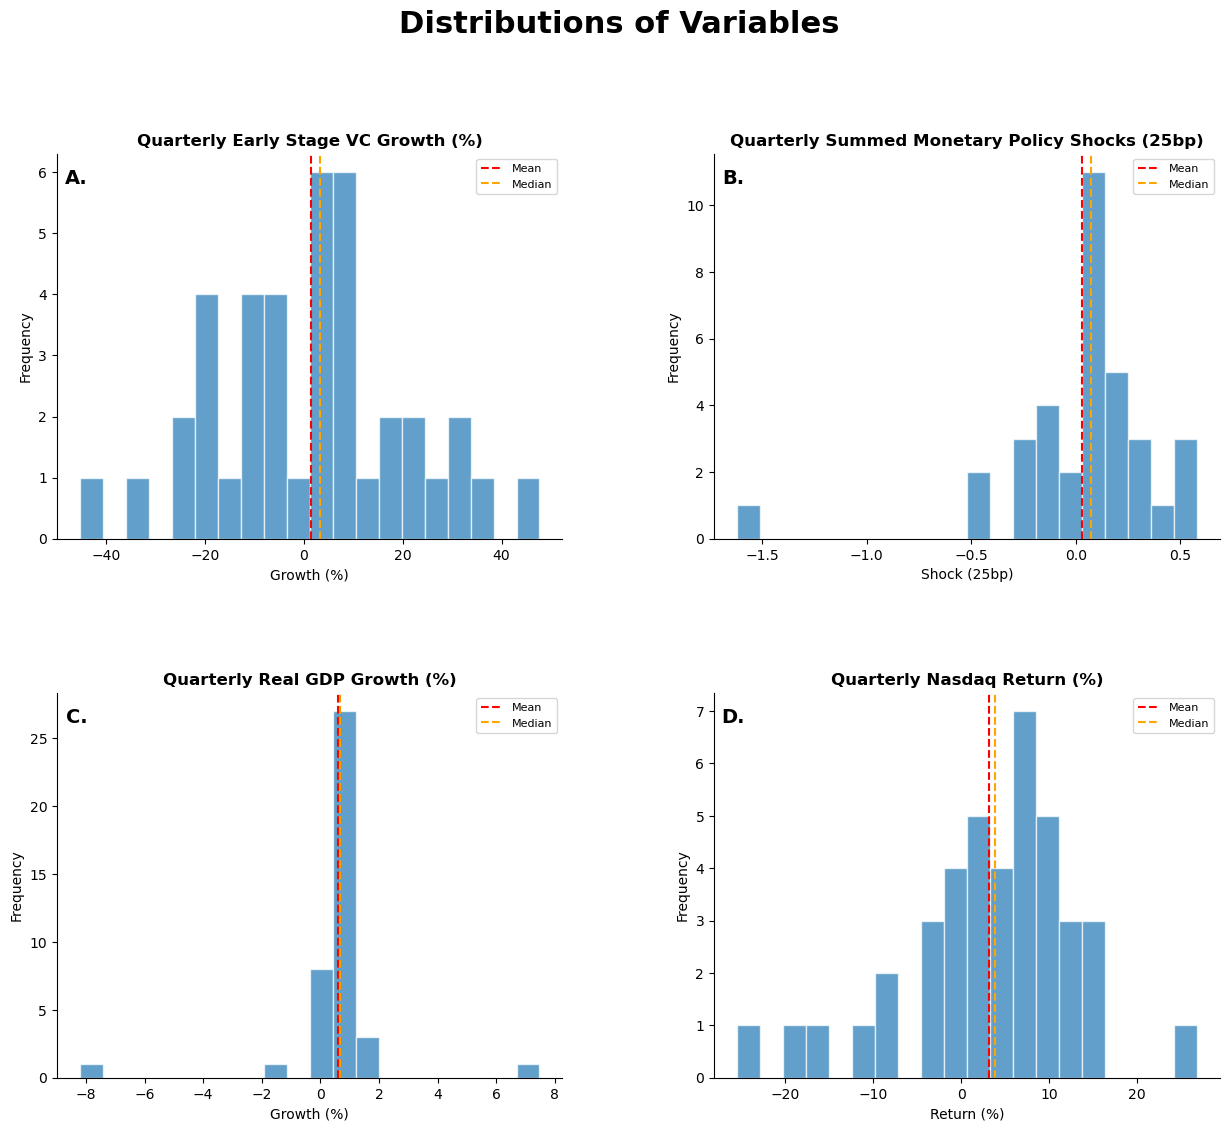

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

variables = ['dlog_vc', 'mps_25bp', 'real_gdp', 'nasdaq_comp_index']

titles = [
    'Quarterly Early Stage VC Growth (%)',
    'Quarterly Summed Monetary Policy Shocks (25bp)',
    'Quarterly Real GDP Growth (%)',
    'Quarterly Nasdaq Return (%)'
]

xlabels = [
    'Growth (%)',
    'Shock (25bp)',
    'Growth (%)',
    'Return (%)'
]

panel_labels = ['A.', 'B.', 'C.', 'D.']

for ax, var, title, xlabel, panel in zip(axes.flatten(), variables, titles, xlabels, panel_labels):
    ax.hist(df_copy[var].dropna(), bins=20, edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.axvline(df_copy[var].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(df_copy[var].median(), color='orange', linestyle='--', label='Median')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel labels
    ax.text(0.06, 0.96, f'{panel}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

fig.suptitle('Distributions of Variables', fontsize=22, fontweight='bold', y=1)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

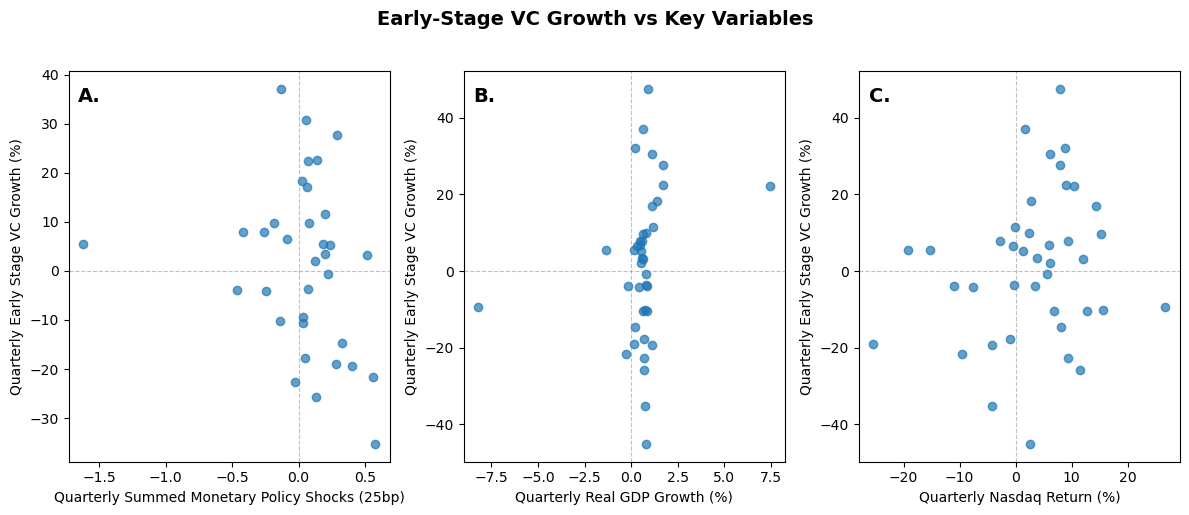

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

x_vars = ['mps_25bp', 'real_gdp', 'nasdaq_comp_index']
x_labels = ['Quarterly Summed Monetary Policy Shocks (25bp)', 'Quarterly Real GDP Growth (%)', 'Quarterly Nasdaq Return (%)']

panel_labels = ['A.', 'B.', 'C.']

for ax, var, label, panel in zip(axes, x_vars, x_labels, panel_labels):
    ax.scatter(df_copy[var], df_copy['dlog_vc'], alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('Quarterly Early Stage VC Growth (%)')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    # Panel labels
    ax.text(0.1, 0.96, f'{panel}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')

fig.suptitle('Early-Stage VC Growth vs Key Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

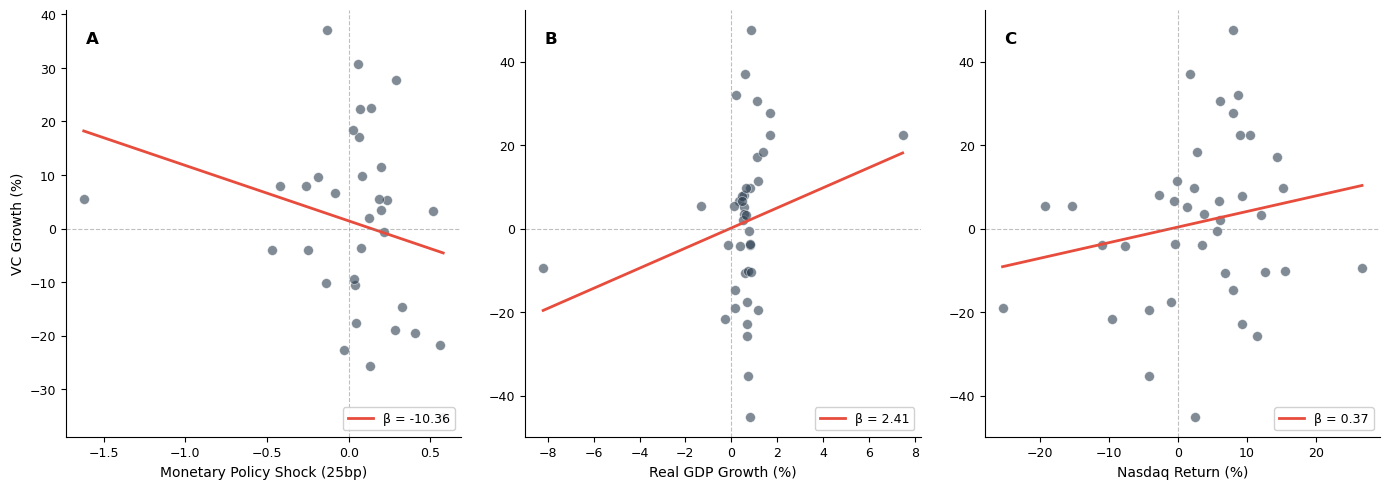

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

variables = ['mps_25bp', 'real_gdp', 'nasdaq_comp_index']

xlabels = [
    'Monetary Policy Shock (25bp)',
    'Real GDP Growth (%)',
    'Nasdaq Return (%)'
]

panel_labels = ['A', 'B', 'C']

for ax, var, xlabel, panel in zip(axes.flatten(), variables, xlabels, panel_labels):
    # Scatter with transparency for overlapping points
    ax.scatter(df_copy[var], df_copy['dlog_vc'], 
               alpha=0.6, color='#2C3E50', edgecolor='white', s=50, linewidth=0.5)
    
    # Add regression line
    mask = df_copy[[var, 'dlog_vc']].dropna().index
    x = df_copy.loc[mask, var]
    y = df_copy.loc[mask, 'dlog_vc']
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), color='#E74C3C', linewidth=2, linestyle='-', label=f'β = {z[0]:.2f}')
    
    # Reference lines at zero
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Labels
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('VC Growth (%)' if panel == 'A' else '', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    
    # Panel label
    ax.text(0.05, 0.95, panel, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
    
    # Legend with slope
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(w_pad=2)
plt.savefig('scatter_panel.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

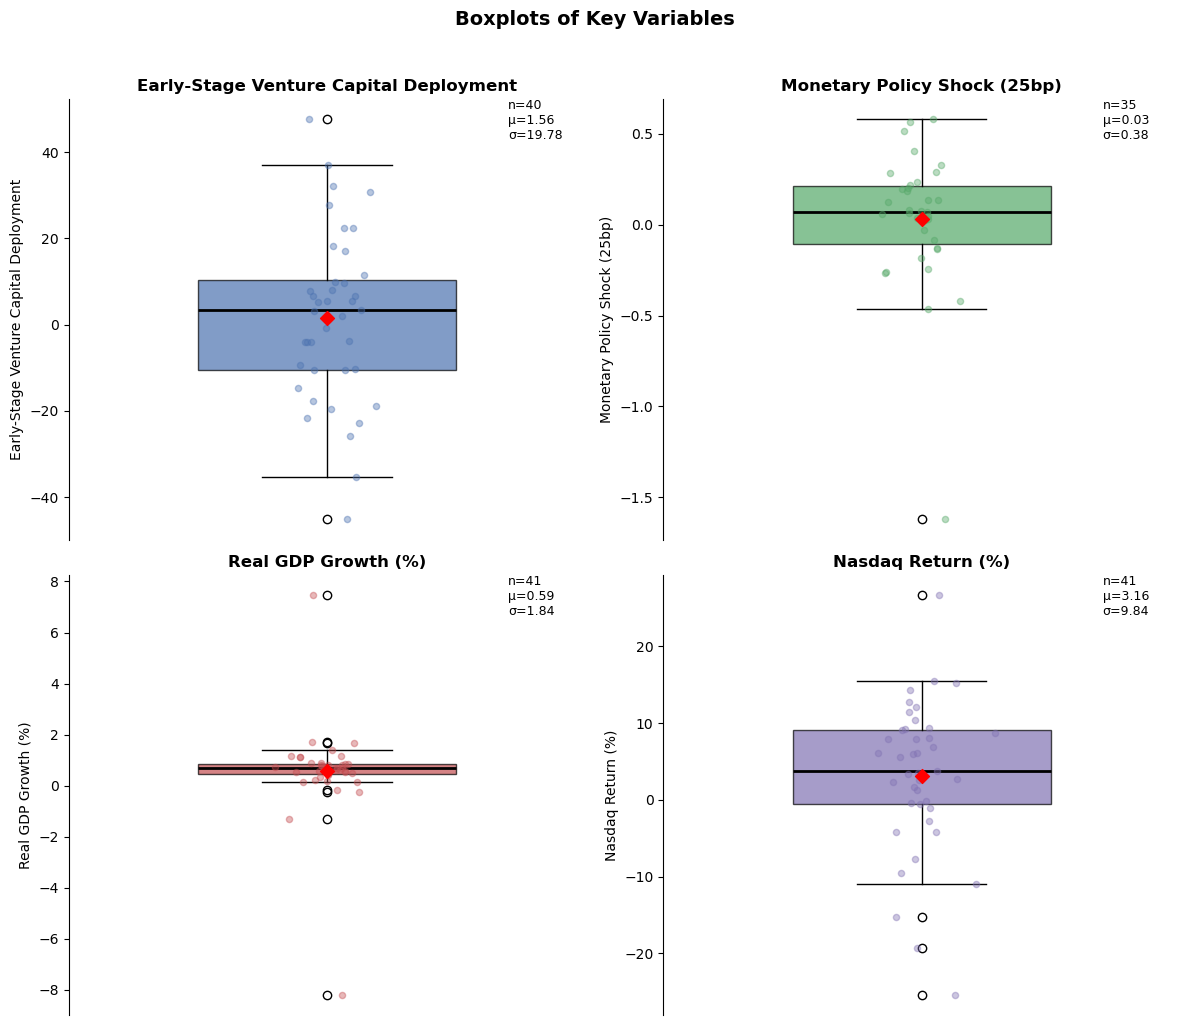

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
variables = ['dlog_vc', 'mps_25bp', 'real_gdp', 'nasdaq_comp_index']
titles = ['Early-Stage Venture Capital Growth', 'Monetary Policy Shock (25bp)', 'Real GDP Growth (%)', 'Nasdaq Return (%)']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

for ax, var, title, color in zip(axes.flatten(), variables, titles, colors):
    data = df_copy[var].dropna()
    
    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5)
    
    # Style the box
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    bp['medians'][0].set_color('black')
    bp['medians'][0].set_linewidth(2)
    
    # Add individual points (jittered)
    x_jitter = np.random.normal(1, 0.04, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.4, color=color, s=20, zorder=3)
    
    # Add mean marker
    ax.scatter(1, data.mean(), color='red', marker='D', s=50, zorder=4, label='Mean')
    
    # Formatting
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title)                                            #CHANGE SPACING BETWEEE BOXES 
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Add summary stats as text
    stats_text = f'n={len(data)}\nμ={data.mean():.2f}\nσ={data.std():.2f}'
    ax.text(1.35, ax.get_ylim()[1], stats_text, fontsize=9, verticalalignment='top')

fig.suptitle('Boxplots of Key Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# correlation matrix
df_copy[["dlog_vc", "mps_25bp", "real_gdp", "nasdaq_comp_index"]].corr()

,dlog_vc,mps_25bp,real_gdp,nasdaq_comp_index
dlog_vc,1.000000,-0.229841,0.226539,0.188011
mps_25bp,-0.229841,1.000000,0.133383,0.109685
real_gdp,0.226539,0.133383,1.000000,-0.084273
nasdaq_comp_index,0.188011,0.109685,-0.084273,1.000000


## Local Projection Model Dataset Creation

In [ ]:
# create dataframe for regression analysis
df_reg = df_copy.copy()

# drop date column
df_reg.drop(columns="date", inplace=True)

# rename for easier interpretation
df_reg = df_reg.rename(columns={"dlog_vc": "es_vc_growth", 
                                "nasdaq_comp_index": "nasdaq_ret"
                       })
df_reg.head()

In [ ]:
# lag nasdaq_ret and t10y2y by 1 quarter
df_reg["nasdaq_ret_l1"]  = df_reg["nasdaq_ret"].shift(1)
df_reg["es_vc_growth_l1"] = df_reg["es_vc_growth"].shift(1)
df_reg

In [ ]:
# reformat and drop NA
df_reg = df_reg[["year", "quarter", "es_vc_growth", "mps_25bp", "nasdaq_ret_l1", "es_vc_growth_l1"]]
# drop NA and reset index correctly
df_reg = df_reg.dropna().reset_index(drop=True)
df_reg

In [ ]:
if not output_path.exists():  
    df_reg.to_csv(output_path, index=False)